# Regresión Lineal Multivariable — Backloggd Games Dataset

Predicción de jugadores (`Plays`) con **3 modelos**:

| # | Modelo | Método |
|---|--------|--------|
| 1 | **Gradiente Descendente** | Optimización iterativa |
| 2 | **Regresión Polinómica** | Features cuadráticas normalizadas |
| 3 | **Ecuación Normal** | Solución analítica θ=(XᵀX)⁻¹Xᵀy |

## 1. Librerías

In [68]:
import csv, re
import numpy as np
from matplotlib import pyplot
#from google.colab import drive
#drive.mount('/content/gdrive')
#print('✓ Librerías cargadas')

## 2. Carga del dataset

Se parsean valores `K`/`M`, se filtran filas incompletas y se aplica **`log1p`** al target `Plays` para estabilizar la distribución sesgada (muchos juegos con pocos jugadores, pocos con millones).

### 2.1 Verificación de características y tipos de datos

El proceso de carga del dataset ya filtra las filas con valores nulos o vacíos en las características clave y convierte todos los valores numéricos a tipo `float`. A continuación, se verifica el estado del array de características `X`.

In [1]:
import pandas as pd
import numpy as np

# Leer dataset
df = pd.read_csv('backloggd_games.csv', encoding='utf-8')
df.head()

,Unnamed: 0,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews
0,0,Elden Ring,"Feb 25, 2022","['FromSoftware', 'Bandai Namco Entertainment']","Elden Ring is a fantasy, action and open world...","['Windows PC', 'PlayStation 4', 'Xbox One', 'P...","['Adventure', 'RPG']",4.5,21K,4.1K,5.6K,5.5K,4.6K,3K
1,1,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",The Legend of Zelda: Breath of the Wild is the...,"['Wii U', 'Nintendo Switch']","['Adventure', 'Puzzle']",4.4,35K,3.1K,5.6K,3K,5.1K,3K
2,2,Hades,"Dec 07, 2018",['Supergiant Games'],A rogue-lite hack and slash dungeon crawler in...,"['Windows PC', 'Mac', 'PlayStation 4', 'Xbox O...","['Adventure', 'Brawler', 'Indie', 'RPG']",4.3,25K,3.5K,7.3K,4K,3.2K,2.1K
3,3,Hollow Knight,"Feb 24, 2017",['Team Cherry'],A 2D metroidvania with an emphasis on close co...,"['Windows PC', 'Mac', 'Linux', 'Nintendo Switch']","['Adventure', 'Indie', 'Platform']",4.4,25K,2.7K,9.6K,2.6K,3.4K,2.1K
4,4,Undertale,"Sep 15, 2015","['tobyfox', '8-4']","A small child falls into the Underground, wher...","['Windows PC', 'Mac', 'Linux', 'PlayStation 4'...","['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",4.2,32K,728,5.7K,2.1K,3.9K,2.5K


In [ ]:
# Parseo vectorizado de valores tipo 1.2K / 3.4M
def parse_k_series(s):
    s = s.astype(str).str.replace(',', '', regex=False).str.strip()
    parts = s.str.extract(r'([0-9.]+)\s*([KkMm]?)')
    num = pd.to_numeric(parts[0], errors='coerce')
    suf = parts[1].str.upper().fillna('')
    factor = np.where(suf == 'M', 1e6, np.where(suf == 'K', 1e3, 1))
    return num * factor

# Columnas numéricas a convertir
num_cols = ['Plays', 'Rating', 'Playing', 'Backlogs', 'Wishlist', 'Lists', 'Reviews']
for c in num_cols:
    df[f'{c}_num'] = parse_k_series(df.get(c, pd.Series(index=df.index, dtype='object')))

# Año de lanzamiento
release_source = df.get('Release_Date', df.get('Release Date', pd.Series(index=df.index, dtype='object')))
df['Release_Year'] = pd.to_datetime(release_source, errors='coerce').dt.year

# Géneros
generos_top = ['RPG', 'Adventure', 'Shooter', 'Action', 'Strategy',
               'Simulation', 'Sports', 'Puzzle', 'Platform', 'Fighting']
genre_cols = [f'genre_{g}' for g in generos_top]
for g in generos_top:
    df[f'genre_{g}'] = df.get('Genres', pd.Series(index=df.index, dtype='object')).astype(str).str.contains(g, case=False, na=False).astype(int)

df['num_genres'] = df[genre_cols].sum(axis=1)

# Conteo de plataformas
df['platforms_count'] = (
    df.get('Platforms', pd.Series(index=df.index, dtype='object'))
      .fillna('')
      .astype(str)
      .str.split(',')
      .apply(lambda x: len([p for p in x if str(p).strip() != '']))
)

# Filtrar filas válidas
required = [
    'Plays_num',
    'Rating_num', 'Playing_num', 'Backlogs_num', 'Wishlist_num', 'Lists_num', 'Reviews_num',
    'Release_Year'
]
df = df.dropna(subset=required).copy()

# Features y target
feature_cols = [
    'Rating_num', 'Playing_num', 'Backlogs_num', 'Wishlist_num', 'Lists_num', 'Reviews_num',
    'Release_Year', 'platforms_count', 'num_genres',
] + genre_cols

X = df[feature_cols].to_numpy(dtype=float)
y_raw = df['Plays_num'].to_numpy(dtype=float)
y = np.log1p(y_raw)
m, n = X.shape

titles = df.get('Title', pd.Series(['?'] * len(df), index=df.index)).fillna('?').tolist()

In [70]:
print(X);
print(y_raw);
print(y);
print(f'm={m} muestras, n={n} features')

[[4.5e+00 4.1e+03 5.6e+03 ... 0.0e+00 0.0e+00 0.0e+00]
 [4.4e+00 3.1e+03 5.6e+03 ... 1.0e+00 0.0e+00 0.0e+00]
 [4.3e+00 3.5e+03 7.3e+03 ... 0.0e+00 0.0e+00 0.0e+00]
 ...
 [7.0e-01 0.0e+00 0.0e+00 ... 1.0e+00 0.0e+00 0.0e+00]
 [3.7e+00 0.0e+00 1.9e+01 ... 0.0e+00 0.0e+00 0.0e+00]
 [3.7e+00 0.0e+00 1.9e+01 ... 0.0e+00 0.0e+00 0.0e+00]]
[2.1e+04 3.5e+04 2.5e+04 ... 3.0e+00 9.0e+00 9.0e+00]
[ 9.95232533 10.46313191 10.1266711  ...  1.38629436  2.30258509
  2.30258509]
m=24859 muestras, n=19 features


## 3. Normalización

$$x_j := \\frac{x_j - \\mu_j}{\\sigma_j}$$

**Crítico para el modelo polinómico:** normalizar *después* de agregar términos cuadráticos evita que los valores exploten y produzcan `nan`.

In [71]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma


In [72]:
# Aplicar log1p a las 6 primeras features continuas antes de normalizar
X[:, :6] = np.log1p(X[:, :6])

X_norm, mu, sigma = featureNormalize(X)
X_b = np.hstack([np.ones((m,1)), X_norm])       # Modelo 1 y 3

# Modelo polinómico: agregar x² de features continuas (primeras 6)
# y normalizar TODO el bloque junto para evitar overflow/nan
X_quad       = np.hstack([X_norm, X_norm[:,:6]**2])   # normalizar ANTES de elevar al cuadrado
X_quad_n, mu_p, sigma_p = featureNormalize(X_quad)           # re-normalizar el bloque completo
X_poly_b     = np.hstack([np.ones((m,1)), X_quad_n])  # Modelo 2

print(f'(Gradiente / Ec.Normal): {X_b.shape}')
print(f'Polinómica: {X_poly_b.shape}')
print(f'X_poly_b: {np.isnan(X_poly_b).sum()}  (debe ser 0)')
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

(Gradiente / Ec.Normal): (24859, 20)
Polinómica: (24859, 26)
X_poly_b: 0  (debe ser 0)
Media calculada: [1.37584255e+00 9.89012779e-01 2.94013928e+00 2.33175100e+00
 2.74676954e+00 1.71210769e+00 2.00980478e+03 2.56196951e+00
 1.24642986e+00 1.88824973e-01 3.85333280e-01 1.66056559e-01
 0.00000000e+00 1.48115371e-01 0.00000000e+00 0.00000000e+00
 1.46546522e-01 1.46707430e-01 6.48457299e-02]
Desviación estandar calculada: [ 0.19905748  1.37365457  1.85460326  1.7492983   1.6102194   1.547159
 10.04851979  2.01132485  0.92518239  0.39136952  0.48667396  0.3721314
  1.          0.35521431  1.          1.          0.35365328  0.35381402
  0.24625345]
[[ 1.65231442  5.33611107  3.06834419 ... -0.41437909 -0.41464561
  -0.26332922]
 [ 1.56013431  5.13263473  3.06834419 ...  2.41324918 -0.41464561
  -0.26332922]
 [ 1.46623112  5.22095679  3.21126758 ... -0.41437909 -0.41464561
  -0.26332922]
 ...
 [-4.24608163 -0.71998653 -1.58531981 ...  2.41324918 -0.41464561
  -0.26332922]
 [ 0.86266519 -

## 4. Funciones: costo, gradiente descendente, ecuación normal

**Costo MSE:**  $J(\\theta)=\\frac{1}{2m}\\|X\\theta - y\\|^2$

**Gradiente:**  $\\theta := \\theta - \\frac{\\alpha}{m} X^T(X\\theta - y)$

**Ec. Normal:** $\\theta = (X^TX)^{-1}X^Ty$

In [73]:
def costo(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento
    J = 0
    h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

def gradiente(X, y, theta, alpha, iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento
    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []
    for i in range(iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(costo(X, y, theta))
    return theta, J_history

def ec_normal(X, y):
    # Usa pseudoinversa para evitar errores cuando X^T X es singular
    return np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    

print('✓ Funciones definidas: costo(), gradiente(), ec_normal()')

✓ Funciones definidas: costo(), gradiente(), ec_normal()


## 5. Modelo 1 — Gradiente Descendente

Se prueban distintos `α` para identificar el que converge más rápido. Luego se entrena con **1500 iteraciones** para asegurar convergencia completa.

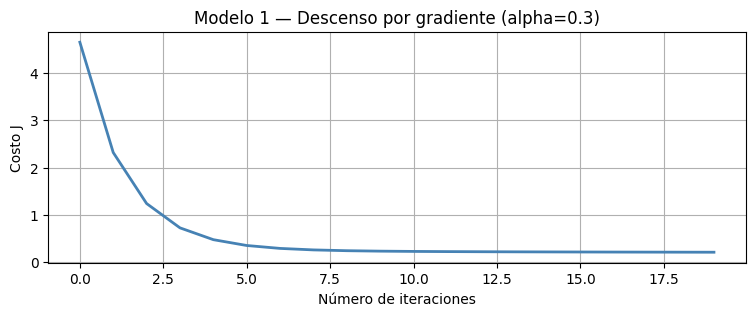

Primeras 100 comparaciones:
Real: 13.00 | Predicho: 10.78
Real: 107.00 | Predicho: 234.15
Real: 90.00 | Predicho: 89.53
Real: 30.00 | Predicho: 27.18
Real: 11.00 | Predicho: 28.45
Real: 6.00 | Predicho: 4.79
Real: 55.00 | Predicho: 20.87
Real: 153.00 | Predicho: 49.49
Real: 20.00 | Predicho: 9.53
Real: 71.00 | Predicho: 51.01
Real: 52.00 | Predicho: 48.33
Real: 93.00 | Predicho: 65.84
Real: 152.00 | Predicho: 48.08
Real: 12.00 | Predicho: 17.00
Real: 108.00 | Predicho: 150.64
Real: 86.00 | Predicho: 68.31
Real: 13.00 | Predicho: 10.41
Real: 67.00 | Predicho: 25.73
Real: 38.00 | Predicho: 28.81
Real: 82.00 | Predicho: 86.62
Real: 112.00 | Predicho: 85.22
Real: 261.00 | Predicho: 125.22
Real: 103.00 | Predicho: 60.10
Real: 44.00 | Predicho: 20.11
Real: 31.00 | Predicho: 54.14
Real: 39.00 | Predicho: 36.72
Real: 4.00 | Predicho: 10.89
Real: 38.00 | Predicho: 28.81
Real: 56.00 | Predicho: 25.86
Real: 39.00 | Predicho: 20.81
Real: 12.00 | Predicho: 30.58
Real: 48.00 | Predicho: 69.56
Real: 

In [74]:
# Elegir un valor para alpha
alpha = 0.3
num_iters = 20

# Entrenar el modelo 1 con descenso por gradiente
theta_gd = np.zeros(X_b.shape[1])
theta_gd, J_gd = gradiente(X_b, y, theta_gd, alpha, num_iters)

pyplot.figure(figsize=(9,3))
pyplot.plot(np.arange(len(J_gd)), J_gd, lw=2, color='steelblue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Modelo 1 — Descenso por gradiente (alpha=0.3)')
pyplot.grid(True)
pyplot.show()

# === ESTIMAR para los últimos 100 valores del dataset ===
X_last = X_b[-100:]
y_last = y_raw[-100:]
y_pred_gd = np.expm1(X_last.dot(theta_gd))

print('Primeras 100 comparaciones:')
for real, pred in zip(y_last[:100], y_pred_gd[:100]):
    print(f'Real: {real:.2f} | Predicho: {pred:.2f}')

# Métricas sobre la escala original de Plays
errors = y_last - y_pred_gd
mse = np.mean(errors ** 2)
ss_res = np.sum(errors ** 2)
ss_tot = np.sum((y_last - np.mean(y_last)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print('MSE últimos 100:', mse)
print('R² últimos 100:', r2)
print(f'Costo inicial : {J_gd[0]:.6f}')
print(f'Costo final   : {J_gd[-1]:.6f}')
print(f'Reducción     : {(1 - J_gd[-1]/J_gd[0])*100:.2f}%')

## 6. Modelo 2 — Regresión Polinómica (grado 2)

Se agregan los cuadrados de las 6 features continuas ya normalizadas. **Clave:** re-normalizar el bloque completo evita que los términos cuadráticos exploten y generen `nan`.

In [75]:
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

theta calculado por el descenso por el gradiente: [ 4.01186431e+00 -6.46866619e-02  2.46334234e-01  3.21870882e-01
  6.11984775e-02  5.01057974e-01  7.70152222e-01 -7.32261955e-02
  5.92761450e-02 -2.03831352e-02 -3.80113944e-02 -5.56493232e-02
  6.78880463e-03  0.00000000e+00  4.66544589e-02  0.00000000e+00
  0.00000000e+00 -1.85221900e-02  7.19652741e-04  4.18211849e-02
 -9.14470114e-02 -9.73319973e-02 -3.27290375e-02 -1.56835544e-01
  1.00788637e-01  1.38910449e-01]
Real: 13.00 | Predicho: 10.13
Real: 107.00 | Predicho: 217.15
Real: 90.00 | Predicho: 89.01
Real: 30.00 | Predicho: 24.87
Real: 11.00 | Predicho: 28.95
Real: 6.00 | Predicho: 5.55
Real: 55.00 | Predicho: 24.86
Real: 153.00 | Predicho: 51.88
Real: 20.00 | Predicho: 8.34
Real: 71.00 | Predicho: 49.79
Costo final: 0.192691


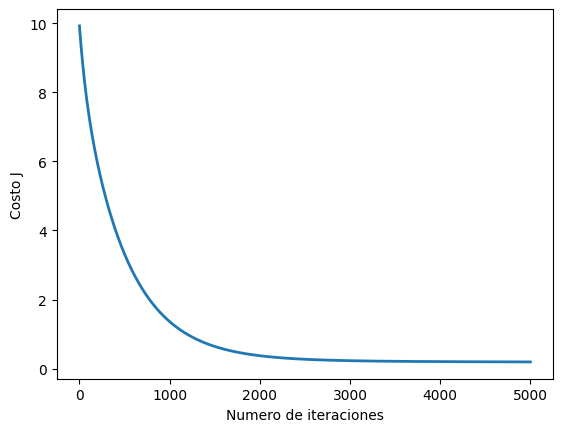

In [76]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001
num_iters = 5000

# inicializa theta y ejecuta el descenso por el gradiente
theta_poly = np.zeros(X_poly_b.shape[1])
theta_poly, J_history = gradiente(X_poly_b, y, theta_poly, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta_poly)))

# Estimar para los últimos 100 registros
X_array = X_poly_b[-100:]          # últimos 100 registros
y_last = y_raw[-100:]
y_pred_poli = np.expm1(np.dot(X_array, theta_poly))

# Mostrar primeras 10 predicciones
for i in range(10):
    print(f"Real: {y_last[i]:.2f} | Predicho: {y_pred_poli[i]:.2f}")
print('Costo final: {:.6f}'.format(J_history[-1]))

## 7. Modelo 3 — Ecuación Normal

Calcula θ exacto sin iterar. Usado sobre los mismos features normalizados del Modelo 1.

$$\\theta = (X^TX)^{-1}X^Ty$$

In [77]:
# Calcular los parámetros con la ecuación normal sobre nuestro dataset
# X_b ya incluye la columna de 1s y y está en log1p(Plays)
theta_ne = ec_normal(X_b, y)

print('Theta calculado a partir de la ecuación de la normal:', str(theta_ne))

# Estimar Plays para los últimos 100 registros
X_last = X_b[-100:]
y_last = y_raw[-100:]
y_pred_ne = np.expm1(X_last @ theta_ne)

# Mostrar primeras 10 predicciones
for i in range(10):
    print(f"Real: {y_last[i]:.2f} | Predicho: {y_pred_ne[i]:.2f}")

Theta calculado a partir de la ecuación de la normal: [ 4.03901095e+00  3.69617915e-02  8.21701415e-02  4.22480025e-01
 -2.92425859e-01  5.36207411e-01  1.08487971e+00 -7.40474656e-02
  4.94200457e-02 -8.27951029e-03 -2.07082169e-02 -4.06567403e-02
  2.74867530e-03  2.77979375e-16  5.06037267e-02 -1.14256427e-16
  0.00000000e+00 -2.28381035e-02 -4.46866715e-03  4.42263671e-02]
Real: 13.00 | Predicho: 11.11
Real: 107.00 | Predicho: 233.25
Real: 90.00 | Predicho: 93.06
Real: 30.00 | Predicho: 24.14
Real: 11.00 | Predicho: 33.49
Real: 6.00 | Predicho: 3.76
Real: 55.00 | Predicho: 15.89
Real: 153.00 | Predicho: 53.96
Real: 20.00 | Predicho: 9.47
Real: 71.00 | Predicho: 69.91


## 9. Gráficas — Real vs Predicho + Error absoluto

Cada punto es una de las 100 muestras. La línea roja `y=x` representa predicción perfecta.

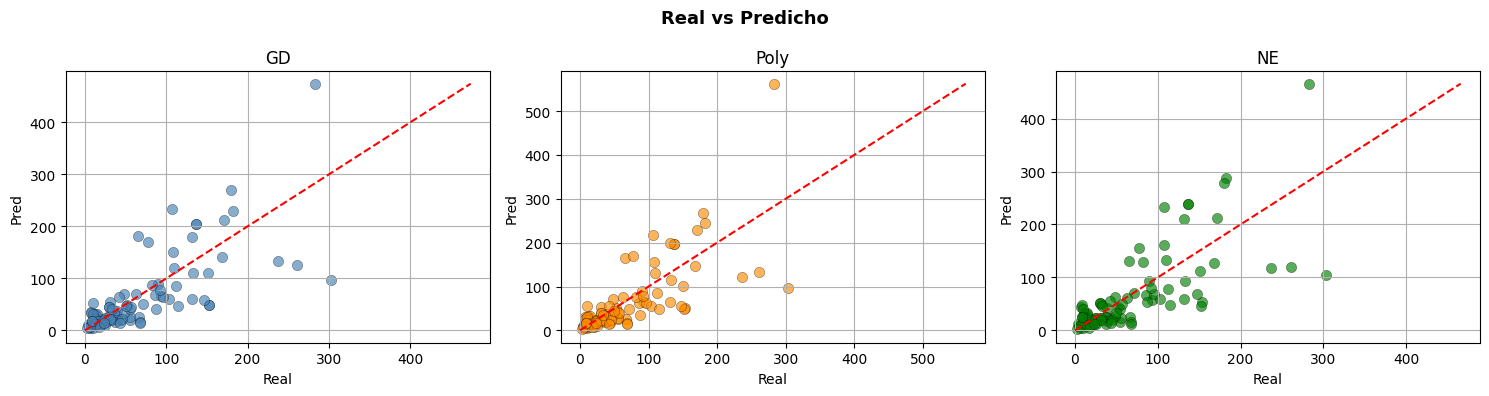

Error absoluto promedio últimos 100 muestras:
  Gradiente   : 30.24
  Polinómico : 30.93
  Normal   : 32.51


In [78]:

# Real vs predicho
fig, axes = pyplot.subplots(1, 3, figsize=(15, 4))
modelos = [
    (y_pred_gd, 'GD', 'steelblue'),
    (y_pred_poli, 'Poly', 'darkorange'),
    (y_pred_ne, 'NE', 'green'),
]

for ax, (pred, nombre, color) in zip(axes, modelos):
    ax.scatter(y_last, pred, alpha=0.65, color=color, edgecolors='k', lw=0.3, s=55)
    limite = [0, max(y_last.max(), pred.max())]
    ax.plot(limite, limite, 'r--', lw=1.5)
    ax.set_title(nombre)
    ax.set_xlabel('Real')
    ax.set_ylabel('Pred')
    ax.grid(True)

pyplot.suptitle('Real vs Predicho', fontsize=13, fontweight='bold')
pyplot.tight_layout()
pyplot.show()

# Error absoluto
print('Error absoluto promedio últimos 100 muestras:')
print(f'  Gradiente   : {np.abs(y_pred_gd - y_last).mean():.2f}')
print(f'  Polinómico : {np.abs(y_pred_poli - y_last).mean():.2f}')
print(f'  Normal   : {np.abs(y_pred_ne - y_last).mean():.2f}')

## 10. Predicción de un juego nuevo

Se normalizan los features del juego nuevo con la misma `mu`/`sigma` del entrenamiento. Para el modelo polinómico se aplica la misma transformación de features cuadráticos.

In [79]:
# [Rating, Playing, Backlogs, Wishlist, Lists, Reviews, Year, Platforms, Num_Genres, genre_flags x10]
x_nuevo = np.array([4.5, 3000, 5000, 4000, 200, 500, 2023, 3, 2,
                    1, 0, 0, 1, 0, 0, 0, 0, 0, 0], dtype=float)

# Aplicar log1p a las 6 primeras features continuas del nuevo juego
x_nuevo[:6] = np.log1p(x_nuevo[:6])

x_n = (x_nuevo - mu) / sigma
x_b = np.r_[1, x_n]

x_quad = np.r_[x_n, x_n[:6]**2]
x_quad_n = (x_quad - mu_p) / sigma_p
x_poly_b = np.r_[1, x_quad_n]

# Reentrena el polinómico si la variable no existe o quedó con otra dimensión
if 'theta_poly' not in globals() or theta_poly.shape[0] != X_poly_b.shape[1]:
    theta_poly = np.zeros(X_poly_b.shape[1])
    theta_poly, _ = gradiente(X_poly_b, y, theta_poly, alpha=0.001, iters=5000)

p_gd = np.expm1(x_b @ theta_gd)
p_poly = np.expm1(x_poly_b @ theta_poly)
p_ne = np.expm1(x_b @ theta_ne)

print('Predicción — juego nuevo (Rating=4.5, RPG+Action, año 2023):')
print(f'  Gradiente Descendente : {p_gd:>10,.0f} jugadores')
print(f'  Regresión Polinómica  : {p_poly:>10,.0f} jugadores')
print(f'  Ecuación Normal       : {p_ne:>10,.0f} jugadores')

Predicción — juego nuevo (Rating=4.5, RPG+Action, año 2023):
  Gradiente Descendente :      8,943 jugadores
  Regresión Polinómica  :      1,552 jugadores
  Ecuación Normal       :      5,865 jugadores
